In [110]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [92]:
df = pd.DataFrame({
    "Screen_Size(inches)": [5.0,5.2,5.5,5.8,6.0,6.2,6.4,6.5,6.7,6.8],
    "Battery_Capacity (mAh)": [3000,3200,3500,3700,4000,4200,pd.NA,4500,4800,5000],
    "Camera_Resolution(MP)": [12,16,20,pd.NA,24,32,48,64,108,200],
    "Price($)": [250,300,350,400,450,500,550,600,700,800]
})

In [93]:
df

,Screen_Size(inches),Battery_Capacity (mAh),Camera_Resolution(MP),Price($)
0,5.0,3000,12,250
1,5.2,3200,16,300
2,5.5,3500,20,350
3,5.8,3700,<NA>,400
4,6.0,4000,24,450
5,6.2,4200,32,500
6,6.4,<NA>,48,550
7,6.5,4500,64,600
8,6.7,4800,108,700
9,6.8,5000,200,800


In [94]:
df.isnull().sum()

Screen_Size(inches)       0
Battery_Capacity (mAh)    1
Camera_Resolution(MP)     1
Price($)                  0
dtype: int64

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Screen_Size(inches)     10 non-null     float64
 1   Battery_Capacity (mAh)  9 non-null      object 
 2   Camera_Resolution(MP)   9 non-null      object 
 3   Price($)                10 non-null     int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 452.0+ bytes


In [96]:
df.describe()

,Screen_Size(inches),Price($)
count,10.000000,10.000000
mean,6.010000,490.000000
std,0.624411,176.068169
min,5.000000,250.000000
25%,5.575000,362.500000
50%,6.100000,475.000000
75%,6.475000,587.500000
max,6.800000,800.000000


In [97]:
df['Battery_Capacity (mAh)'] = df['Battery_Capacity (mAh)'].fillna(df['Battery_Capacity (mAh)'].mean())

C:\Users\DELL\AppData\Local\Temp\ipykernel_16732\1426060090.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Battery_Capacity (mAh)'] = df['Battery_Capacity (mAh)'].fillna(df['Battery_Capacity (mAh)'].mean())


In [98]:
df

,Screen_Size(inches),Battery_Capacity (mAh),Camera_Resolution(MP),Price($)
0,5.0,3000.000000,12,250
1,5.2,3200.000000,16,300
2,5.5,3500.000000,20,350
3,5.8,3700.000000,<NA>,400
4,6.0,4000.000000,24,450
5,6.2,4200.000000,32,500
6,6.4,3988.888889,48,550
7,6.5,4500.000000,64,600
8,6.7,4800.000000,108,700
9,6.8,5000.000000,200,800


In [99]:
df['Camera_Resolution(MP)'] = df['Camera_Resolution(MP)'].fillna(df['Camera_Resolution(MP)'].median())

C:\Users\DELL\AppData\Local\Temp\ipykernel_16732\1067694478.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Camera_Resolution(MP)'] = df['Camera_Resolution(MP)'].fillna(df['Camera_Resolution(MP)'].median())


In [100]:
df

,Screen_Size(inches),Battery_Capacity (mAh),Camera_Resolution(MP),Price($)
0,5.0,3000.000000,12.0,250
1,5.2,3200.000000,16.0,300
2,5.5,3500.000000,20.0,350
3,5.8,3700.000000,32.0,400
4,6.0,4000.000000,24.0,450
5,6.2,4200.000000,32.0,500
6,6.4,3988.888889,48.0,550
7,6.5,4500.000000,64.0,600
8,6.7,4800.000000,108.0,700
9,6.8,5000.000000,200.0,800


<Axes: xlabel='Screen_Size(inches)', ylabel='Price($)'>

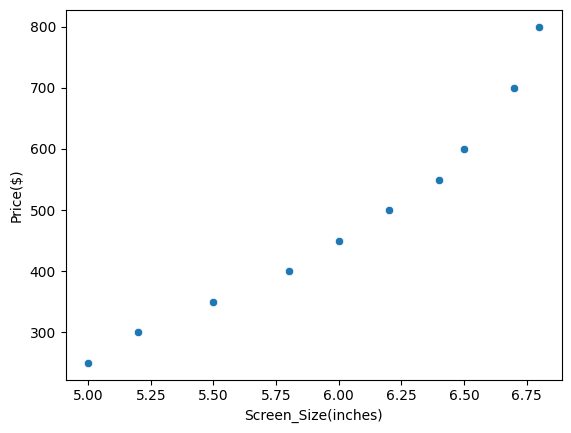

In [101]:
sns.scatterplot(data=df,x = 'Screen_Size(inches)',y = 'Price($)')

In [102]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values


In [103]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [104]:
print(X_train)

[[   6.8        5000.          200.        ]
 [   5.2        3200.           16.        ]
 [   6.4        3988.88888889   48.        ]
 [   6.5        4500.           64.        ]
 [   5.8        3700.           32.        ]
 [   5.         3000.           12.        ]
 [   6.2        4200.           32.        ]]


In [105]:
print(X_test)

[[   5.5 3500.    20. ]
 [   6.7 4800.   108. ]
 [   6.  4000.    24. ]]


In [106]:
print(y_train)

[800 300 550 600 400 250 500]


In [107]:
print(y_test)

[350 700 450]


In [108]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [112]:
y_pred = model.predict(X_test)

In [114]:
print("r2_score: ",r2_score(y_test,y_pred))
print("mean_squared_error: ",mean_squared_error(y_test,y_pred))

r2_score:  0.9939980261582811
mean_squared_error:  130.04276657057443


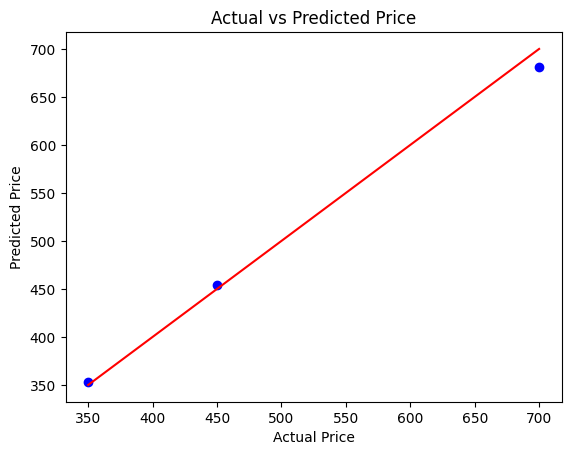

In [115]:
plt.scatter(y_test, y_pred, color="blue")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.show()